# 02 — CNN Embeddings and Unsupervised Clustering of RGC Images

Use a pretrained ResNet18 model as an image feature extractor, then run PCA/UMAP and unsupervised clustering.

No image labels are required.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

import torch
from torchvision import models, transforms

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

plt.style.use("default")

If needed, install:

```bash
pip install torch torchvision scikit-learn umap-learn pillow pandas numpy matplotlib
```

In [3]:
data_dir = Path("../data/cropped")
output_dir = Path("../outputs/rgc_image_analysis")
fig_dir = output_dir / "figures"

output_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

image_paths = sorted(
    list(data_dir.glob("*.tif")) +
    list(data_dir.glob("*.tiff")) +
    list(data_dir.glob("*.png")) +
    list(data_dir.glob("*.jpg")) +
    list(data_dir.glob("*.jpeg"))
)

filenames = [p.name for p in image_paths]

print("Number of images:", len(image_paths))

Number of images: 45


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x[:3]),
    transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std)
])

print("Using device:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/jg/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|███████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:00<00:00, 110MB/s]


Using device: cuda


In [5]:
embeddings = []

with torch.no_grad():
    for path in image_paths:
        img = Image.open(path).convert("L")
        x = preprocess(img).unsqueeze(0).to(device)

        embedding = feature_extractor(x)
        embedding = embedding.squeeze().detach().cpu().numpy()

        embeddings.append(embedding)

embeddings = np.vstack(embeddings)

embedding_df = pd.DataFrame(embeddings)
embedding_df.insert(0, "filename", filenames)

embedding_path = output_dir / "rgc_resnet18_embeddings.csv"
embedding_df.to_csv(embedding_path, index=False)

print("Embedding shape:", embeddings.shape)
print("Saved embeddings:")
print(embedding_path)

Embedding shape: (45, 512)
Saved embeddings:
../outputs/rgc_image_analysis/rgc_resnet18_embeddings.csv


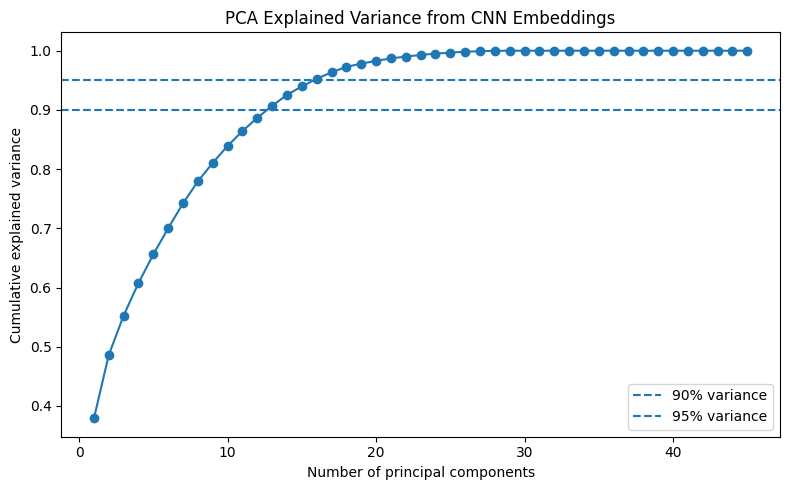

Saved:
../outputs/rgc_image_analysis/figures/cnn_embedding_pca_explained_variance.tiff


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(embeddings)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained = np.cumsum(pca_full.explained_variance_ratio_)

fig = plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained) + 1), explained, marker="o")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance from CNN Embeddings")
plt.legend()
plt.tight_layout()

out_path = fig_dir / "cnn_embedding_pca_explained_variance.tiff"
fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:")
print(out_path)

In [7]:
n_pca_components = min(10, X_scaled.shape[0] - 1, X_scaled.shape[1])

pca = PCA(n_components=n_pca_components)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)

PCA shape: (45, 10)


In [8]:
cluster_range = range(2, min(12, len(image_paths)))

rows = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)

    rows.append({
        "method": "kmeans",
        "k": k,
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": kmeans.inertia_
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df)

metrics_path = output_dir / "rgc_kmeans_k_comparison_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("Saved metrics:")
print(metrics_path)

,method,k,silhouette,inertia
0,kmeans,2,0.537181,11681.165039
1,kmeans,3,0.546957,9795.325195
2,kmeans,4,0.546267,8461.515625
3,kmeans,5,0.439069,7259.402832
4,kmeans,6,0.446268,6263.032227
5,kmeans,7,0.436781,5458.029785
6,kmeans,8,0.443286,4425.703125
7,kmeans,9,0.450021,3688.468506
8,kmeans,10,0.442432,2930.027100
9,kmeans,11,0.472470,2334.468750


Saved metrics:
../outputs/rgc_image_analysis/rgc_kmeans_k_comparison_metrics.csv


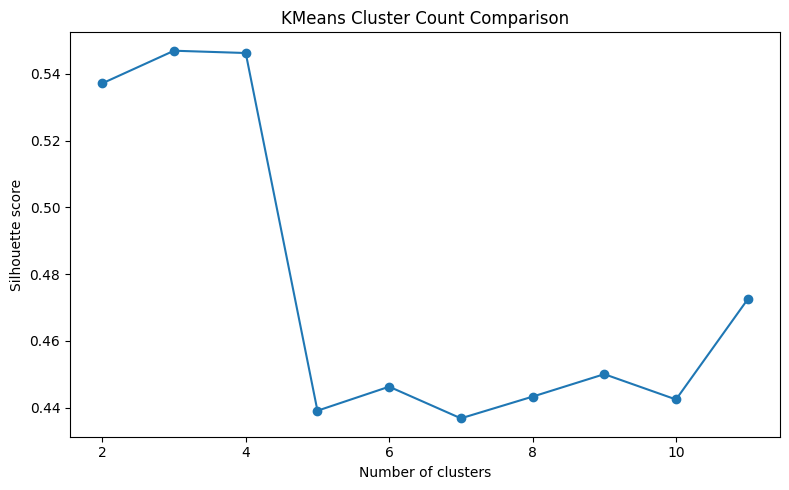

Saved:
../outputs/rgc_image_analysis/figures/rgc_kmeans_silhouette_scores.tiff


In [9]:
fig = plt.figure(figsize=(8, 5))
plt.plot(metrics_df["k"], metrics_df["silhouette"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("KMeans Cluster Count Comparison")
plt.tight_layout()

out_path = fig_dir / "rgc_kmeans_silhouette_scores.tiff"
fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:")
print(out_path)

In [10]:
# Choose this after reviewing the images and silhouette curve.
# With 44 images, visually compare k=2 through k=6 first.
selected_k = 4

kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init=20)
labels_kmeans = kmeans.fit_predict(X_pca) + 1

hierarchical = AgglomerativeClustering(n_clusters=selected_k, linkage="ward")
labels_hierarchical = hierarchical.fit_predict(X_pca) + 1

ari = adjusted_rand_score(labels_kmeans, labels_hierarchical)

print("Selected k:", selected_k)
print("KMeans vs hierarchical adjusted Rand index:", ari)

Selected k: 4
KMeans vs hierarchical adjusted Rand index: 0.9226463899592464


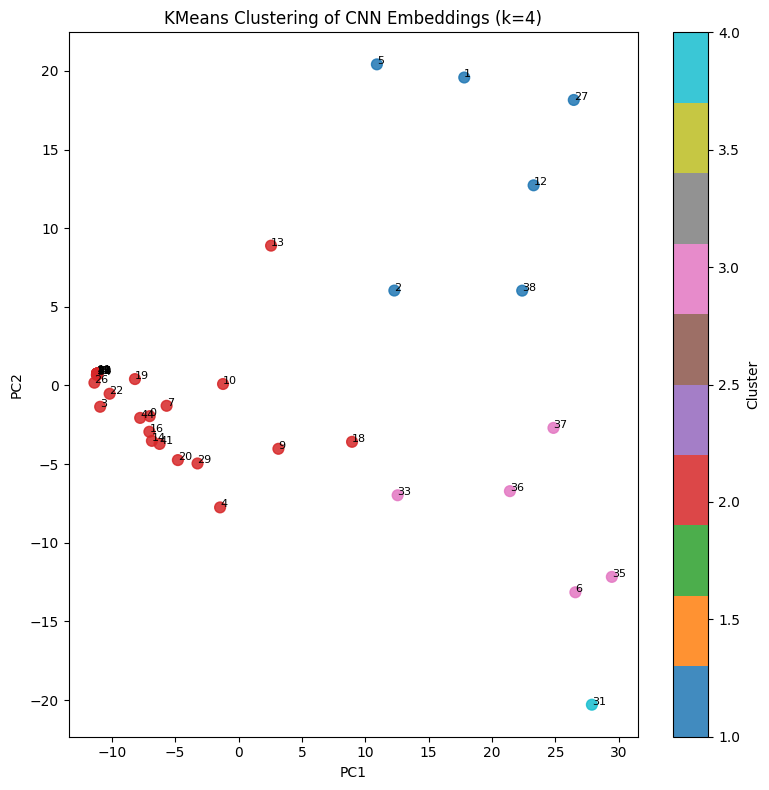

Saved:
../outputs/rgc_image_analysis/figures/rgc_kmeans_pca_clusters.tiff


In [11]:
fig = plt.figure(figsize=(8, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap="tab10", s=60, alpha=0.85)

for i, name in enumerate(filenames):
    plt.text(X_pca[i, 0], X_pca[i, 1], str(i), fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clustering of CNN Embeddings (k={selected_k})")
plt.colorbar(label="Cluster")
plt.tight_layout()

out_path = fig_dir / "rgc_kmeans_pca_clusters.tiff"
fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:")
print(out_path)

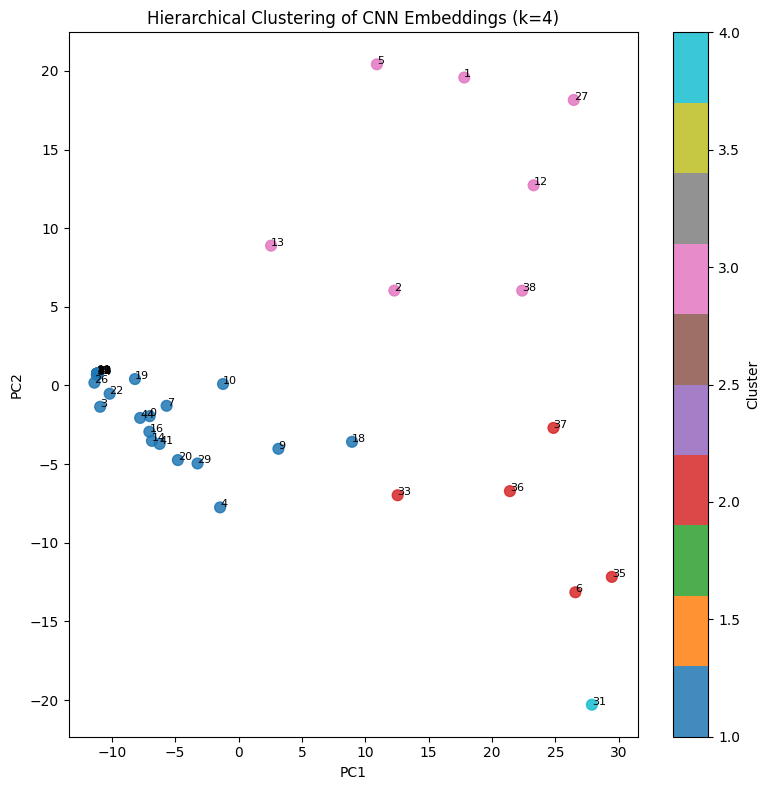

Saved:
../outputs/rgc_image_analysis/figures/rgc_hierarchical_pca_clusters.tiff


In [12]:
fig = plt.figure(figsize=(8, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hierarchical, cmap="tab10", s=60, alpha=0.85)

for i, name in enumerate(filenames):
    plt.text(X_pca[i, 0], X_pca[i, 1], str(i), fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Hierarchical Clustering of CNN Embeddings (k={selected_k})")
plt.colorbar(label="Cluster")
plt.tight_layout()

out_path = fig_dir / "rgc_hierarchical_pca_clusters.tiff"
fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:")
print(out_path)

/home/jg/miniconda3/envs/neuropixels/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


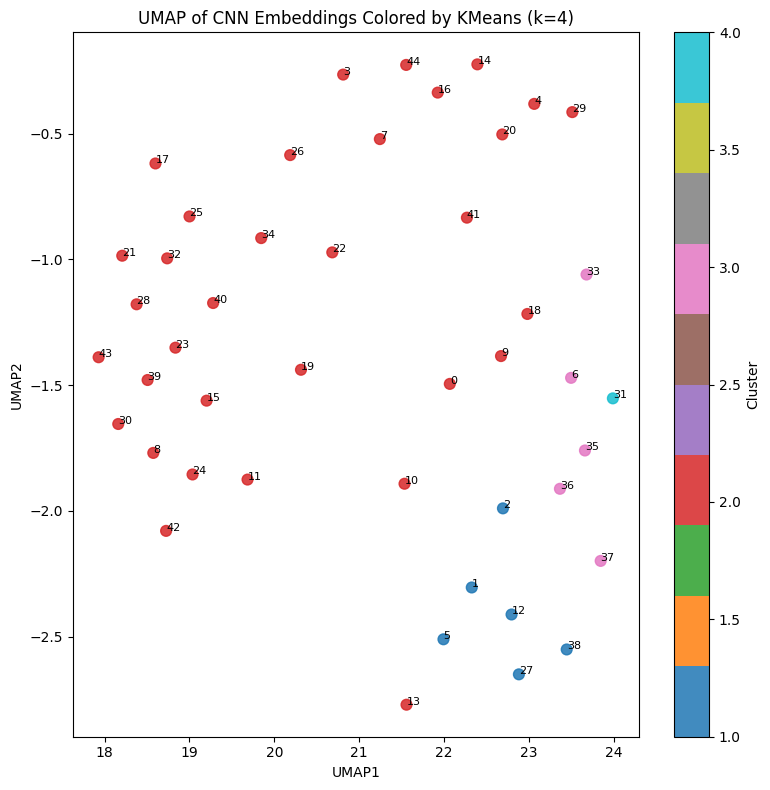

Saved:
../outputs/rgc_image_analysis/figures/rgc_umap_kmeans_clusters.tiff


In [15]:
if UMAP_AVAILABLE:
    reducer = umap.UMAP(
        # n_neighbors=min(15, len(image_paths) - 1),
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )

    X_umap = reducer.fit_transform(X_scaled)

    fig = plt.figure(figsize=(8, 8))
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_kmeans, cmap="tab10", s=60, alpha=0.85)

    for i, name in enumerate(filenames):
        plt.text(X_umap[i, 0], X_umap[i, 1], str(i), fontsize=8)

    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title(f"UMAP of CNN Embeddings Colored by KMeans (k={selected_k})")
    plt.colorbar(label="Cluster")
    plt.tight_layout()

    out_path = fig_dir / "rgc_umap_kmeans_clusters.tiff"
    fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Saved:")
    print(out_path)
else:
    print("UMAP is not installed. Install with: pip install umap-learn")

In [16]:
cluster_assignments = pd.DataFrame({
    "image_index": np.arange(len(filenames)),
    "filename": filenames,
    "kmeans_cluster": labels_kmeans,
    "hierarchical_cluster": labels_hierarchical
})

assignment_path = output_dir / "rgc_cluster_assignments.csv"
cluster_assignments.to_csv(assignment_path, index=False)

display(cluster_assignments)

print("Saved cluster assignments:")
print(assignment_path)

,image_index,filename,kmeans_cluster,hierarchical_cluster
0,0,cropped0.tif,2,1
1,1,cropped1.tif,1,3
2,2,cropped10.tif,1,3
3,3,cropped11.tif,2,1
4,4,cropped12.tif,2,1
5,5,cropped13.tif,1,3
6,6,cropped14.tif,3,2
7,7,cropped15.tif,2,1
8,8,cropped16.tif,2,1
9,9,cropped17.tif,2,1


Saved cluster assignments:
../outputs/rgc_image_analysis/rgc_cluster_assignments.csv


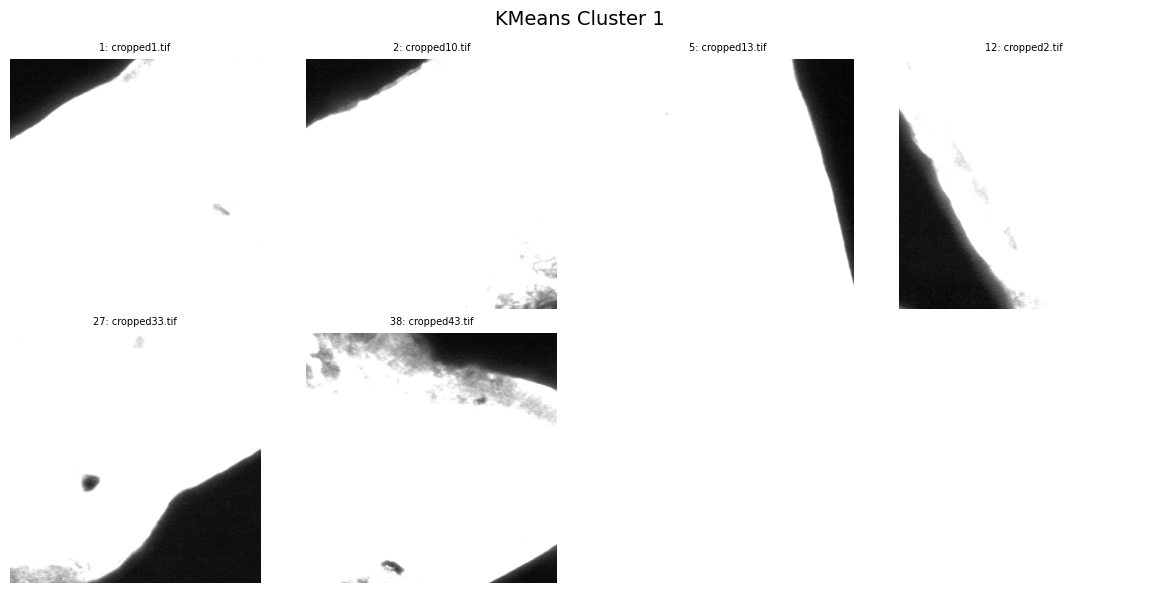

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_1_contact_sheet.tiff


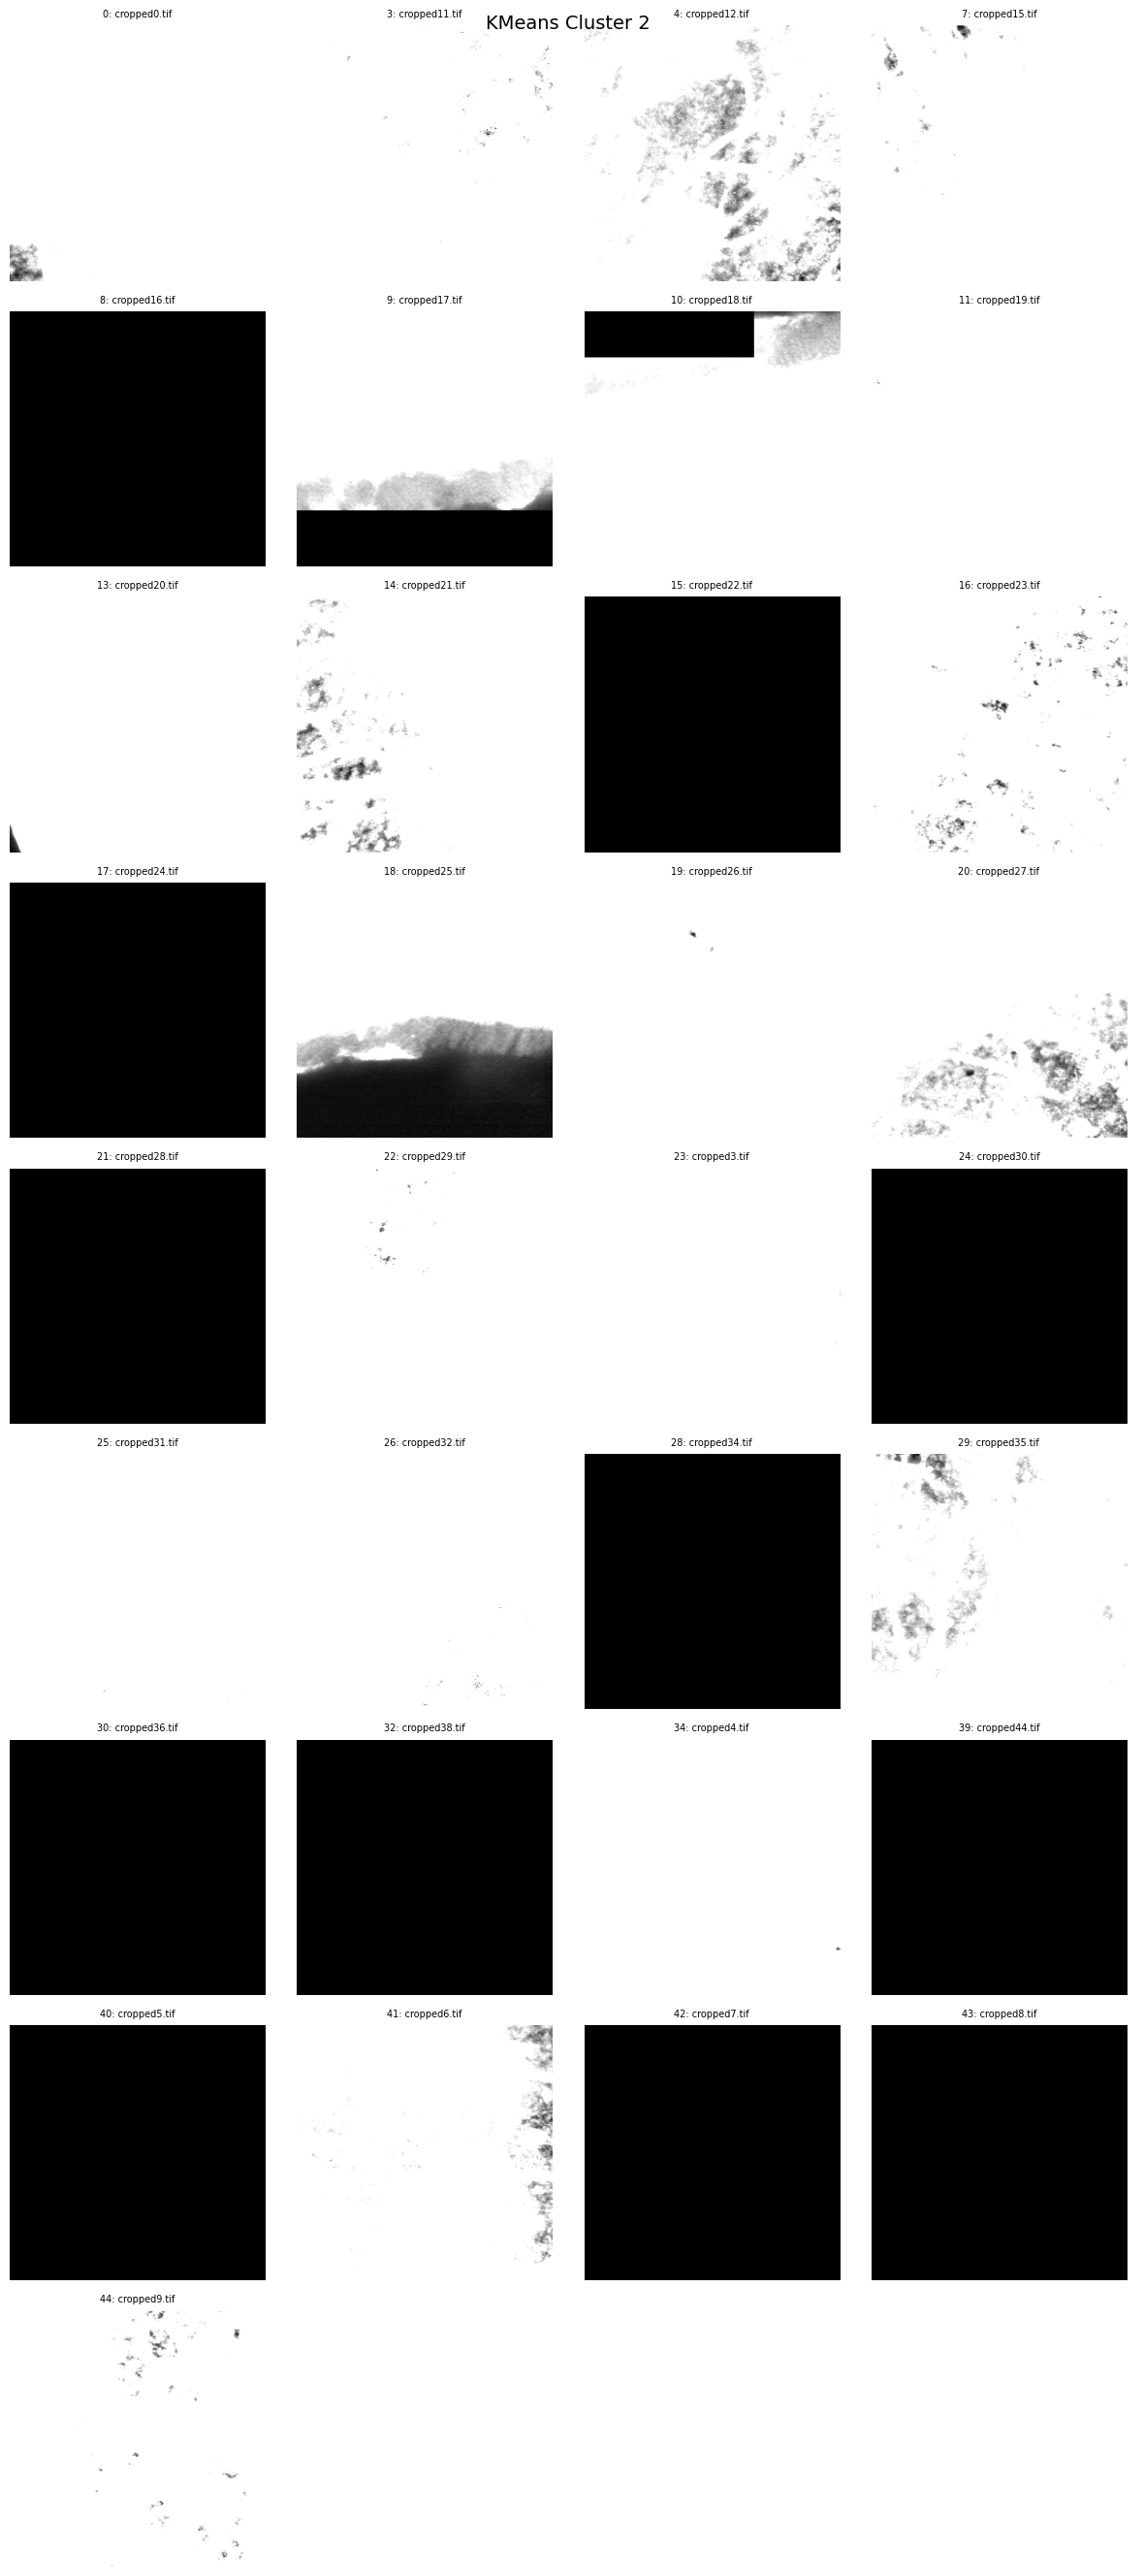

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_2_contact_sheet.tiff


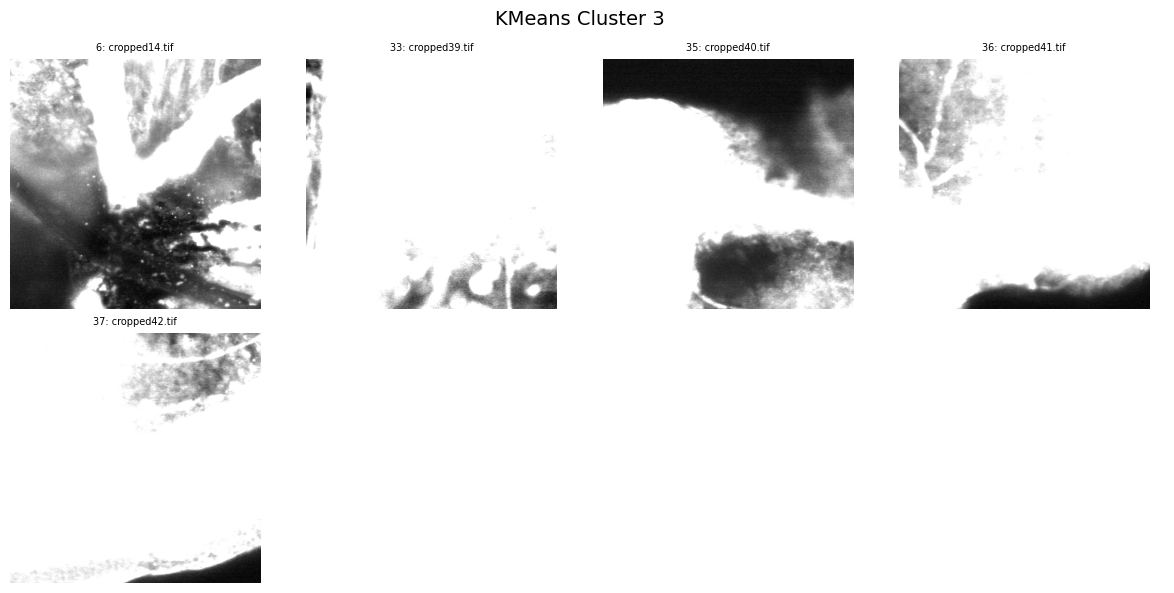

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_3_contact_sheet.tiff


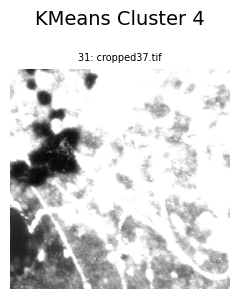

Saved: ../outputs/rgc_image_analysis/figures/rgc_kmeans_cluster_4_contact_sheet.tiff


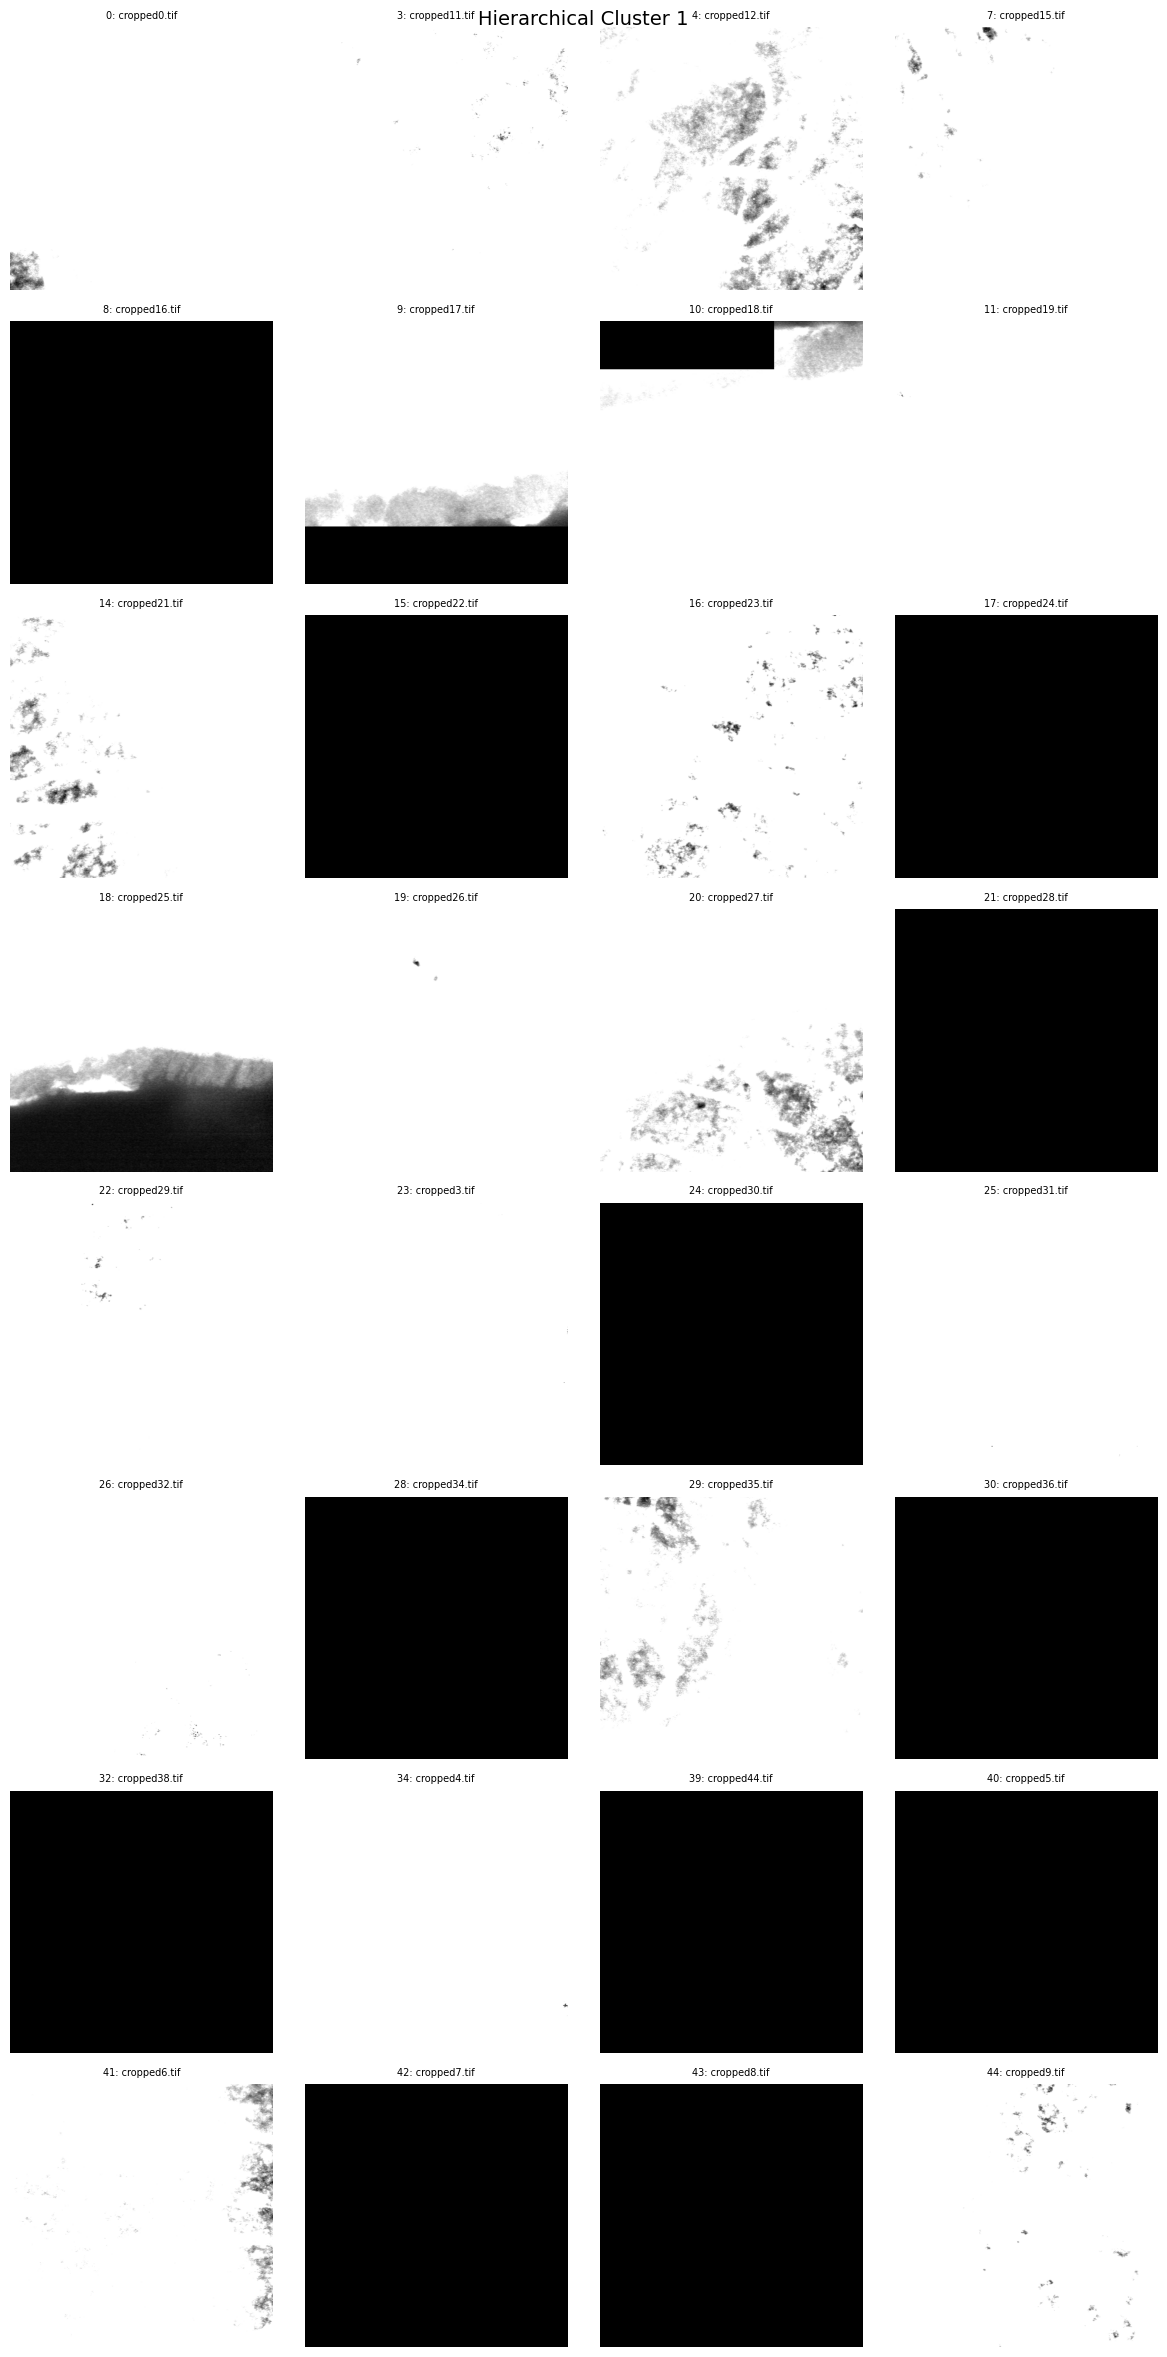

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_1_contact_sheet.tiff


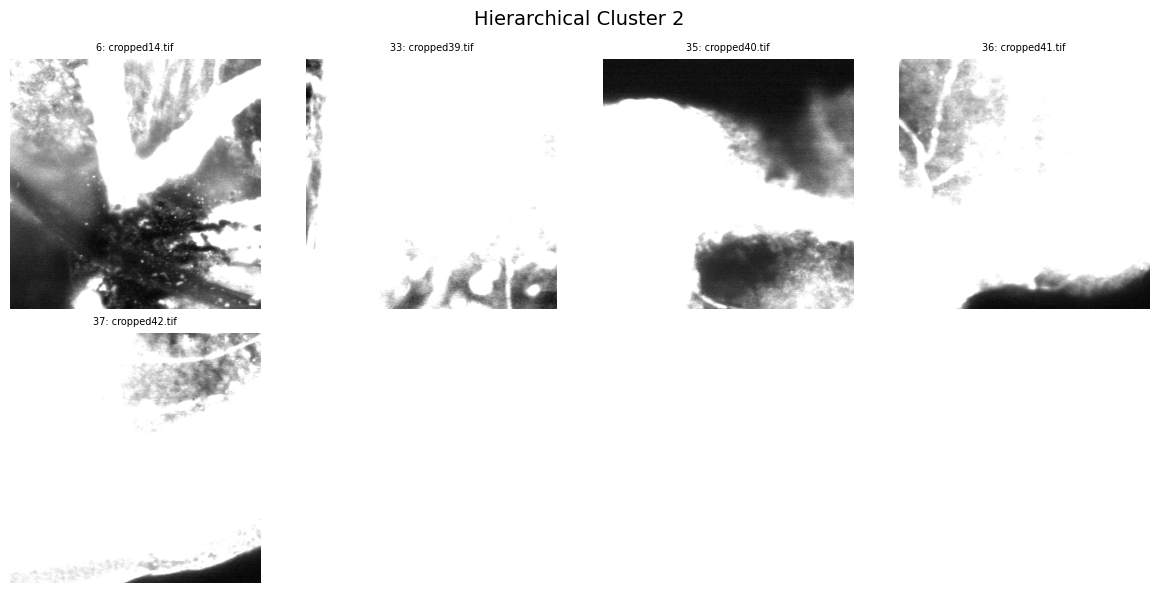

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_2_contact_sheet.tiff


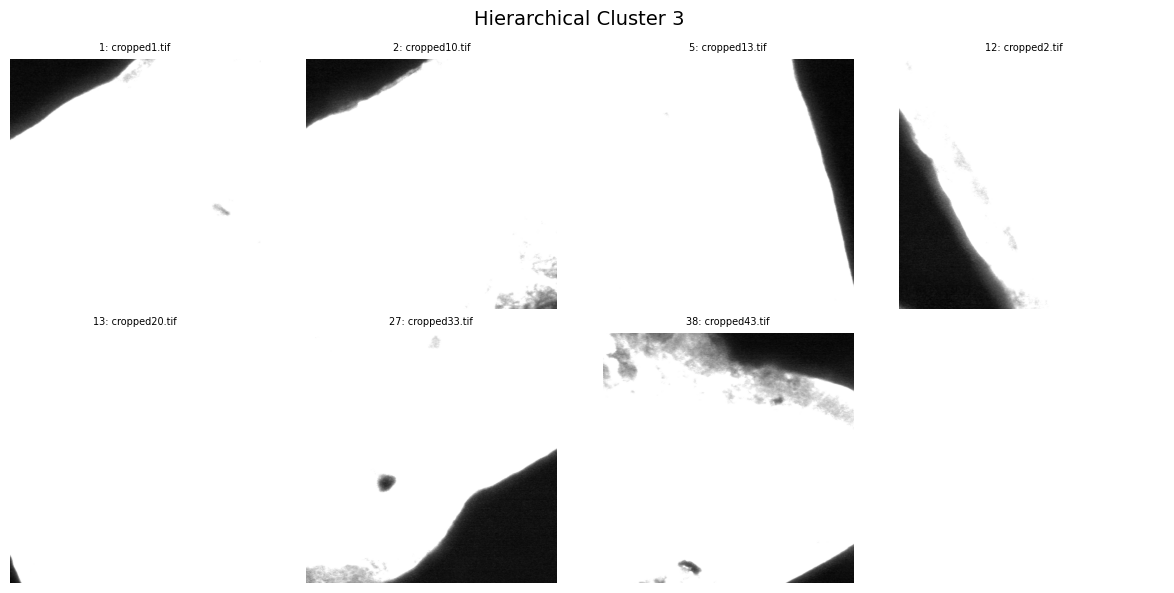

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_3_contact_sheet.tiff


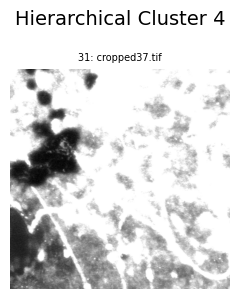

Saved: ../outputs/rgc_image_analysis/figures/rgc_hierarchical_cluster_4_contact_sheet.tiff


In [17]:
def plot_cluster_contact_sheets(labels, method_name):
    labels = np.asarray(labels)
    unique_clusters = sorted(np.unique(labels))

    for cluster in unique_clusters:
        idxs = np.where(labels == cluster)[0]

        n_show = len(idxs)
        n_cols = min(4, n_show)
        n_rows = int(np.ceil(n_show / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
        axes = np.array(axes).reshape(-1)

        for ax, idx in zip(axes, idxs):
            img = Image.open(image_paths[idx]).convert("L")
            ax.imshow(img, cmap="gray")
            ax.set_title(f"{idx}: {filenames[idx]}", fontsize=7)
            ax.axis("off")

        for ax in axes[n_show:]:
            ax.axis("off")

        plt.suptitle(f"{method_name} Cluster {cluster}", fontsize=14)
        plt.tight_layout()

        out_path = fig_dir / f"rgc_{method_name.lower()}_cluster_{cluster}_contact_sheet.tiff"
        fig.savefig(out_path, dpi=300, format="tiff", bbox_inches="tight")
        plt.show()
        plt.close(fig)

        print("Saved:", out_path)

plot_cluster_contact_sheets(labels_kmeans, "KMeans")
plot_cluster_contact_sheets(labels_hierarchical, "Hierarchical")